# 60 TPD Melter — How the Recommenders Were Trained, Tested and Used

This notebook explains **how the two recommenders were built**, **how we checked them honestly**, and **why we chose the final versions**. It ends with the **recommendation function**: enter the current plant values and get the setpoints, plus a back-test against your history for the same conditions.

| | Gas recommender | Barrier-boost recommender |
|---|---|---|
| **Recommends** | NG flow, secondary air, air-fuel ratio | barrier boost (kWh/h) |
| **How often** | every 20-min reversal cycle (ready by minute 15) | every hour |
| **Built from** | your 15-min and daily history | your hourly MB3 and boost history |

**Contents**
1. Terms used in this notebook
2. The data the models learn from
3. How we tested: walk-forward, two test periods and a validation month
4. The gas model: what we tried, what we chose, how it builds a target
5. Secondary air and the air-fuel ratio
6. The barrier-boost model
7. Results of the complete recommender
8. Safety: every setpoint stays inside the furnace's proven limits
9. **The recommendation function** (enter values → setpoints)
10. **Back-test of your inputs against history**
11. How it will be used in the trial

In [1]:
import report as R
import recommender as rc
import pandas as pd, numpy as np
R.setup()
D = R.Data()
print('Usable days: %d (%s to %s)' % (len(D.u), D.u.index.min().date(), D.u.index.max().date()))

Usable days: 343 (2025-10-11 to 2026-09-29)


---
## 1. Terms used in this notebook
| Term | Meaning |
|---|---|
| **Model** | An equation or rule that turns inputs (draw, NCV, boost, …) into a recommendation |
| **Training** | Fitting the model's numbers to past data |
| **Gas-heat target** | The gas heat (Gcal/day) the furnace should need today. NG = target ÷ 96 intervals ÷ latest NCV |
| **Regression (OLS)** | Fitting a straight-line equation, e.g. `gas = a + b × draw + …`, by least squares |
| **Quantile regression** | A regression that aims at a percentile (e.g. the 25th) instead of the average |
| **LightGBM** | A machine-learning method (many decision trees). Tested as an alternative |
| **"25% shift" (conformal shift)** | Moves the regression's average prediction down to the level that only the best 25% of recent days reached, using the errors of the last 45 days |
| **Coverage** | Share of days that actually used less gas than the target. It should be about **25%**. Much lower means the target is too hard; much higher means too easy |
| **Error score (pinball loss)** | The standard accuracy score for a 25th-percentile target. **Lower is better** |
| **Walk-forward** | Each day is predicted only from the days *before* it, as in real use |
| **Test period** | Months the model did not train on and is scored on: Mar–May 2026 and Jun–Aug 2026 |
| **Validation month** | A month kept apart and only checked at the end: Sep 2026 |
| **Air per Mcal** | Secondary air per Mcal of gas heat (SCM/Mcal) |
| **AFR** | Air-fuel ratio = secondary air ÷ NG |
| **MB3** | Melter bottom thermocouple 3 (°C) |
| **Step response** | How MB3 changes over the hours after a lasting change in barrier boost |
| **Integral controller** | Each hour, adds a small correction proportional to the gap between MB3 and its target |
| **Closed-loop replay** | Re-running history hour by hour with our boost: MB3 = actual MB3 + the effect of our boost changes |
| **P1–P99 limits** | The range that covers 98% of the furnace's own history; the recommenders never go outside it |
| **Draw-adjusted %** | Energy vs what the baseline period needed at the same draw and cullet; target −2% |
| **5-t band** | Days grouped by draw (45–50, 50–55, 55–60, 60–65 t), each with its own baseline SFC |

---
## 2. The data the models learn from
| Step | Rule |
|---|---|
| Source | 15-minute analytical record (corrected file of 5 Oct 2026) and the 1-minute crown thermocouple. **Your workbook values are not used as inputs** |
| NCV | Kept only between 8,500 and 10,500 kcal/SCM, and not more than 400 away from the median of the surrounding ~2 hours (spikes). Zeros removed |
| Gas heat | Σ (NG × NCV of the same 15 minutes), never daily NG × average NCV |
| Gaps | Gaps up to 1 hour in gas, boost and air are filled by interpolation; longer gaps are left empty |
| Draw | Doubled values on 1 Oct 2025, 1 Jun 2026 and 1 Sep 2026 are halved |
| Usable day | NCV valid ≥ 90% of the day, gas and boost data complete, draw present |

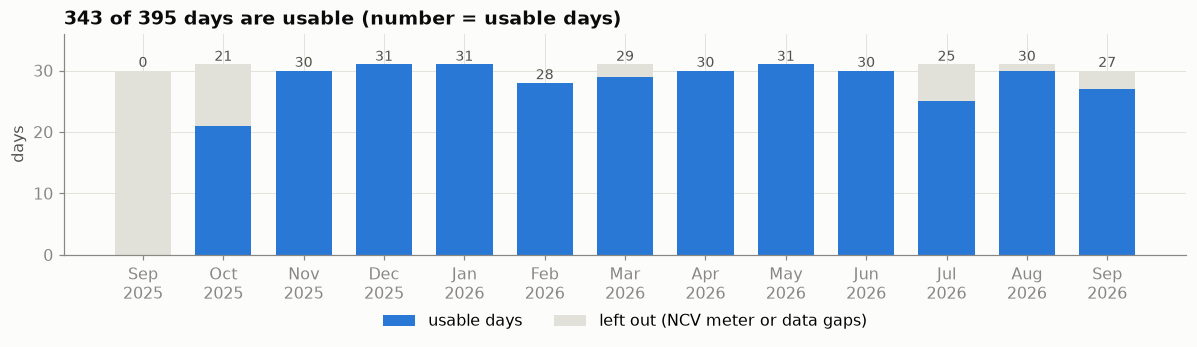

In [2]:
R.chart_coverage(D)

---
## 3. How we tested: honest, walk-forward, on months the model never saw
A model that only fits the past is easy to build and useless in practice. **What matters is how it performs on days it hasn't seen.** So:
- **Walk-forward:** to recommend for a day, the model is trained only on the days **before** it, exactly as it would run live.
- **Two test periods:** every candidate was scored on **Mar–May 2026** and on **Jun–Aug 2026**. A winner must be good in **both**, not just one lucky period.
- **One validation month:** **Sep 2026** was only checked at the end.

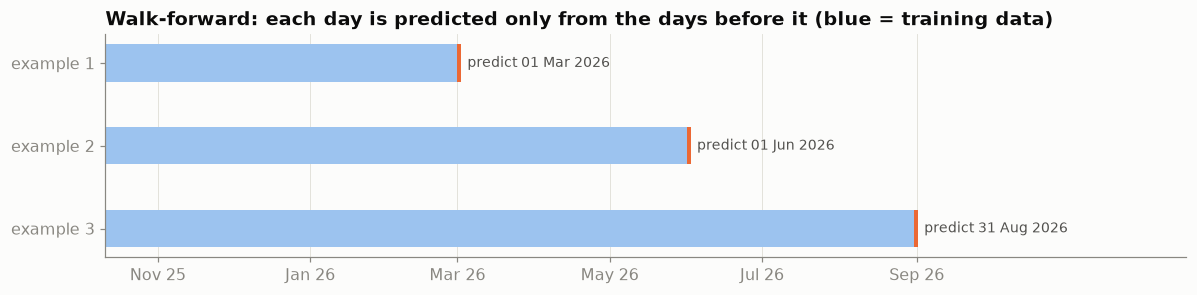

In [3]:
R.chart_walk_forward()

---
## 4. The gas model
### 4.1 What the model must do
Every day it sets a **gas-heat target**: the gas the furnace should need today, given the draw, the boost and the furnace's age. The target should be **ambitious but realistic**: about what the **most efficient quarter** of comparable recent days needed. Then:

`NG setpoint (per 15 min) = gas-heat target ÷ 96 ÷ latest NCV`

### 4.2 Which model type? Eight candidates, scored on both test periods

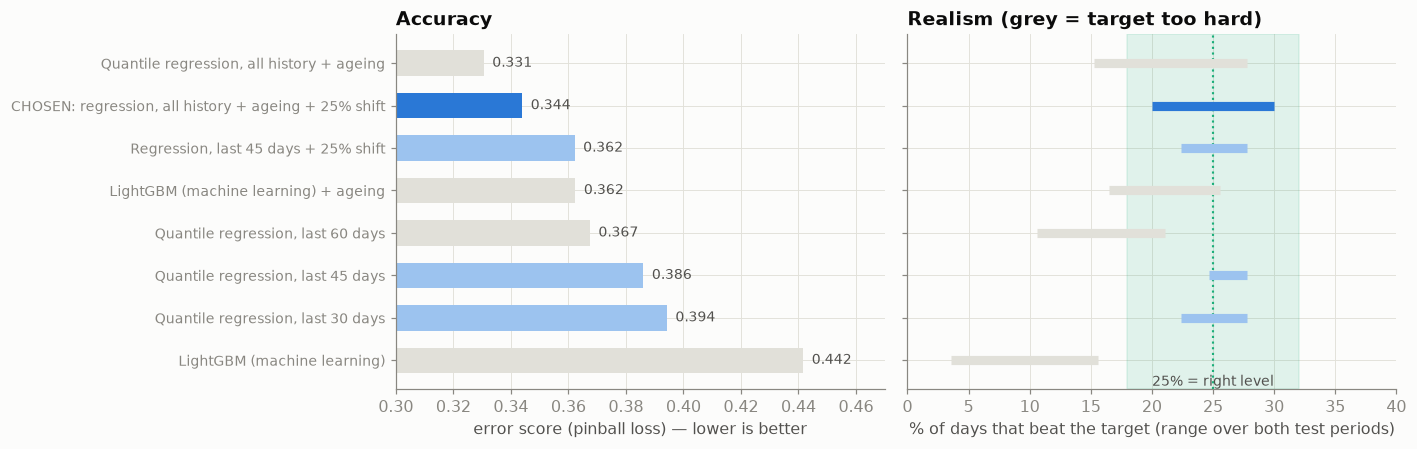

In [4]:
R.chart_gas_candidates(D)

**Reading the chart**
- **Left (accuracy):** lower is better.
- **Right (realism):** the bar shows the range of "% of days that beat the target" over the two test periods. It should sit around 25% (the green band).
- **Grey models look good on accuracy only because their targets are too hard.** For example, only 11–21% of days beat the 60-day quantile regression, and only 4–16% beat LightGBM. In a trial, operators would see targets the furnace rarely reaches, override them, and lose trust.
- **LightGBM (machine learning) was the weakest.** With about 300 days of data, a tree model can't learn more than a simple equation, and it extrapolates poorly.
- **Chosen (dark blue):** a **regression on all past days + furnace age + the 25% shift**. It is the most accurate model whose targets stay realistic in **both** periods.

### 4.3 Which inputs? Tested inside the chosen model type

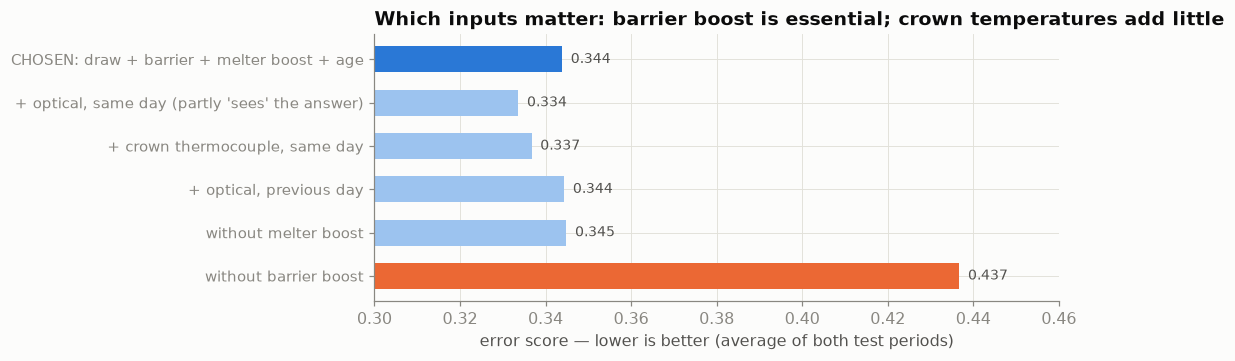

In [5]:
R.chart_gas_inputs(D)

**Reading the chart**
- **Barrier boost is essential** (orange): without it the error rises by about 27%. Boost heat replaces part of the gas, so the model must know how much boost is on.
- **Crown temperature (optical or thermocouple)** adds little or nothing.
  - The same-day value looks slightly better only because it partly "sees" the day's own firing.
  - The previous-day optical scores the same as no crown input, and on the validation month (Sep 2026) it made the target too easy (41% of days beat it instead of 25%).
  - **So optical is used as a safety check, not as a model input.**
- **Melter boost** makes no difference to accuracy. It is kept because it is part of the furnace's energy, and its value is read from the database.
- **Cullet and MB3** were also tested and add nothing reliable.

### 4.4 The final gas model: a transparent equation
Trained on **all usable days**:

In [6]:
FR = rc.FinalRecommender().fit(D.d, D.q, D.h)
gm = FR.gas_model
coef = pd.DataFrame({'value': gm.params.round(3).values, 'statistically significant?': ['', 'yes', 'yes', 'no', 'yes'],
                     'meaning': ['base level (Gcal/day)', 'Gcal/day more gas per +1 t/day draw',
                                 'Gcal of gas saved per Gcal of barrier boost', 'Gcal of gas saved per Gcal of melter boost',
                                 'Gcal/day more gas per month of furnace age']},
                    index=['constant', 'draw (t/day)', 'barrier boost (Gcal/day)', 'melter boost (Gcal/day)', 'furnace age (months)'])
print('Trained on %d usable days up to %s | 25%% shift from the last 45 days: %+.2f Gcal/day' % (int(gm.nobs), FR.trained_until.date(), FR.conformal_shift))
coef

Trained on 343 usable days up to 2026-09-29 | 25% shift from the last 45 days: -0.41 Gcal/day


,value,statistically significant?,meaning
constant,52.195,,base level (Gcal/day)
draw (t/day),0.495,yes,Gcal/day more gas per +1 t/day draw
barrier boost (Gcal/day),-0.771,yes,Gcal of gas saved per Gcal of barrier boost
melter boost (Gcal/day),-0.099,no,Gcal of gas saved per Gcal of melter boost
furnace age (months),0.350,yes,Gcal/day more gas per month of furnace age


**How a daily target is built** (example: today, draw 58 t, barrier boost 350 kWh/h, melter boost 300 kWh/h):

| Part | Calculation | Gcal/day |
|---|---|---|
| constant | | 52.20 |
| draw | 0.495 × 58 | +28.71 |
| barrier boost | −0.771 × (350 × 24 × 860 ÷ 10⁶ = 7.22) | −5.57 |
| melter boost | −0.099 × (300 × 24 × 860 ÷ 10⁶ = 6.19) | −0.61 |
| furnace age | 0.350 × 13.1 months | +4.59 |
| 25% shift | efficient quarter of the last 45 days | −0.41 |
| **target** | | **≈ 78.9** |

Then, if NCV is 9,300: NG = 78.9 × 10⁶ ÷ 96 ÷ 9,300 = **88.4** per 15 min. If NCV moves to 9,600: NG = **85.6**. The heat stays the same.

**Every number has a physical meaning** that an engineer can check: more draw needs more gas, boost replaces part of the gas, an older furnace needs more. That transparency matters for trust in a trial.

### 4.5 How the gas target performed on days it had not seen (Jun–Sep 2026)

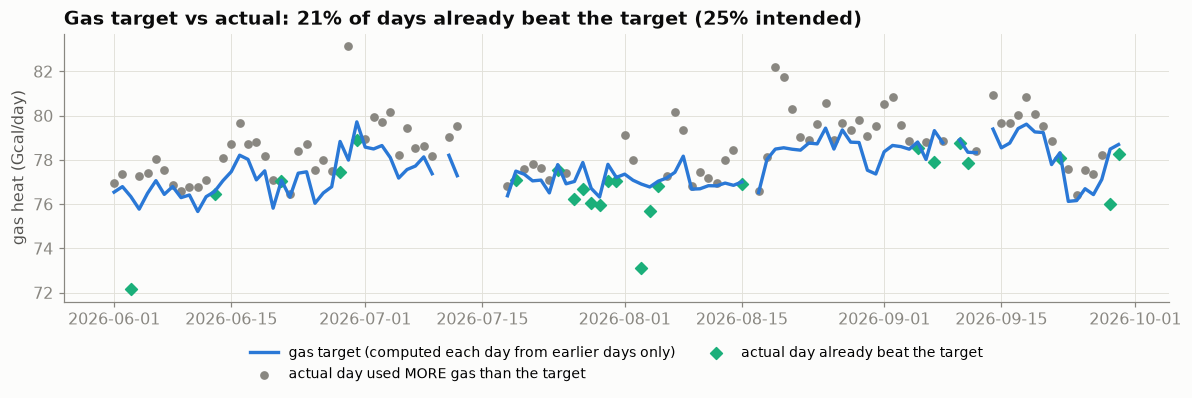

Jun-Aug 2026 (test)    days 85 | beat the target: 20% (25% intended) | average error 1.04 Gcal/day
Sep 2026 (validation)  days 27 | beat the target: 26% (25% intended) | average error 0.90 Gcal/day


In [7]:
tgt = R.gas_targets(D, '2026-06-01', '2026-09-30')
R.chart_gas_target_vs_actual(D, tgt)
a = D.u.loc[tgt.index, 'gas_g']
for name, (s, e) in {'Jun-Aug 2026 (test)': ('2026-06-01', '2026-08-31'), 'Sep 2026 (validation)': ('2026-09-01', '2026-09-30')}.items():
    t_, a_ = tgt[s:e], a[s:e]
    print('%-22s days %d | beat the target: %.0f%% (25%% intended) | average error %.2f Gcal/day' % (name, len(t_), 100 * (a_ <= t_).mean(), (a_ - t_).abs().mean()))

**Reading:** in both the test period and the validation month, about **a quarter of days already used less gas than the target**. The target is ambitious and still realistic. On the other days, following the target means firing less gas than was actually used.

---
## 5. Secondary air and the air-fuel ratio
### 5.1 What does secondary air follow?

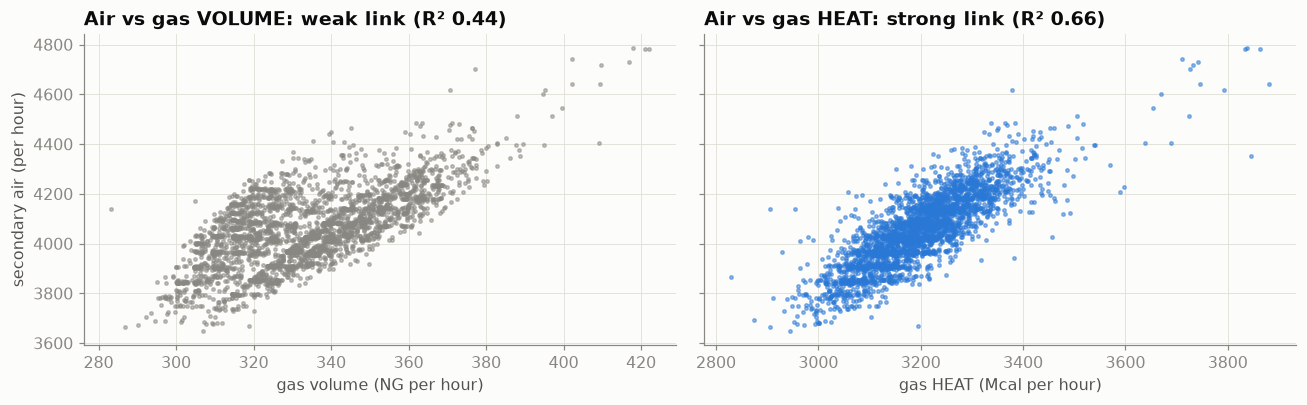

In [8]:
R.chart_air_follows_heat(D)

Air follows the gas **heat**, not the gas **volume**. When NCV is higher, each SCM of gas needs more oxygen. So the right quantity to control is **air per Mcal of gas heat**, not a fixed AFR.

### 5.2 Which formula, which level?
| Formula tried (scored hour by hour, walk-forward) | Error (% of air) |
|---|---|
| fixed AFR × NG | 3.32% (worst: ignores NCV) |
| **air per Mcal × gas heat (chosen)** | **1.50%** |
| regression on gas heat + NCV | 1.42% |
| regression on gas heat | 1.45% |

The chosen formula is almost as accurate as the regressions, simpler, and physically meaningful (oxygen per unit of heat).

**Which level of air per Mcal?** Days with less air per Mcal used less energy (see the insights notebook). There is **no O₂ analyser**, so the target is:
- **the 25th percentile of the last 45 days** (the efficient end of recent operation), and
- **never below the historical 5th percentile** (1.226 SCM/Mcal).

**Recommendation:** `secondary air = air-per-Mcal target × gas heat`, and `AFR = secondary air ÷ NG`.

---
## 6. The barrier-boost model
### 6.1 How MB3 responds to barrier boost

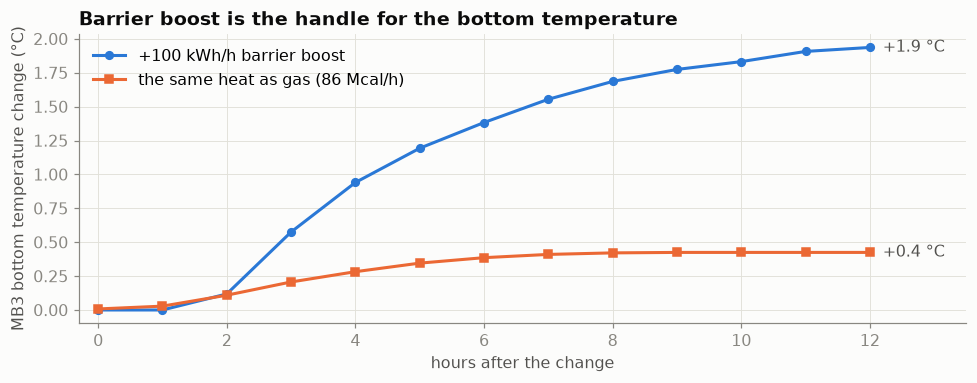

In [9]:
R.chart_boost_mb3(D)

Measured from your hourly data with a **distributed-lag model**. MB3's change in each hour is related to the boost and gas changes of the previous 0–12 hours, which separates the furnace's response from operators' reactions. **+100 kWh/h of barrier boost raises MB3 by about 1.9 °C after 6–12 hours.** This number (0.0194 °C per kWh/h) is what the controller uses.

### 6.2 Which policy? Four candidates, replayed hour by hour on both test periods

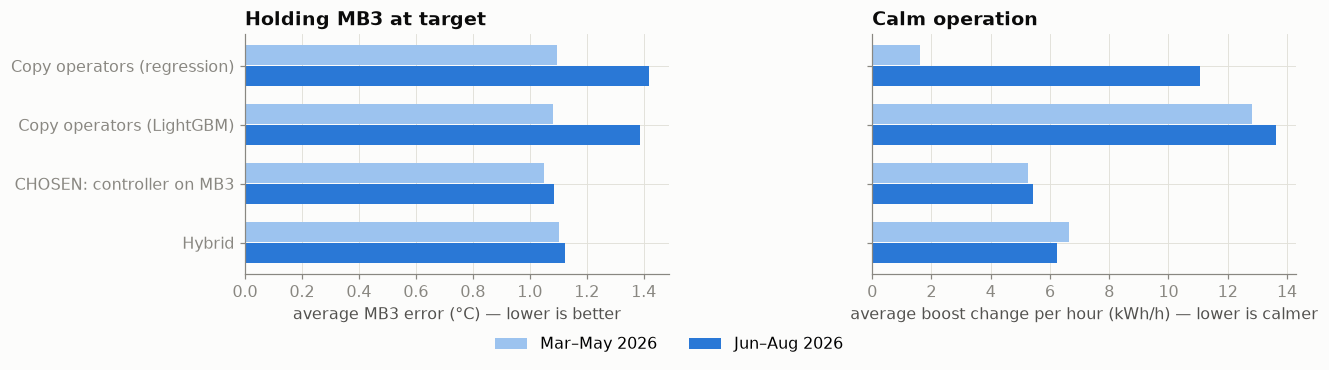

In [10]:
R.chart_boost_policies(D)

- **Copy operators (regression, as in the original design):** reproduces past habits, including running MB3 hot in summer. Its key coefficient changed from −0.6 to −22 kWh/h per °C between the two periods, so it is **not stable**.
- **Copy operators (LightGBM):** the same idea, with jumpy boost moves.
- **Controller on MB3 (chosen):** the best MB3 tracking in both periods, with small, calm hourly changes:

  `boost next hour = boost last hour + 0.1 × (MB3 target − MB3 now) ÷ 0.0194`

  - **MB3 target** = 1,320.25 °C, the furnace's historical median.
  - **0.1** means each hour it corrects 10% of the gap, because the furnace responds slowly.
- **Hybrid:** no better, and more complex.

**Draw, cullet and melter boost** are not needed in the controller: the hourly MB3 feedback absorbs their effect. Melter boost was tested specifically:

| Check | Result |
|---|---|
| Effect of a melter-boost change on MB3 | real but temporary: peak +1.8 °C per +100 kWh/h after ~4 h, fading to +0.6 °C |
| Better MB3 forecast with it? | no (R² 0.540 → 0.537 and 0.531 → 0.532) |
| Controller with a melter-boost correction | MB3 error unchanged (< 0.01 °C difference) |

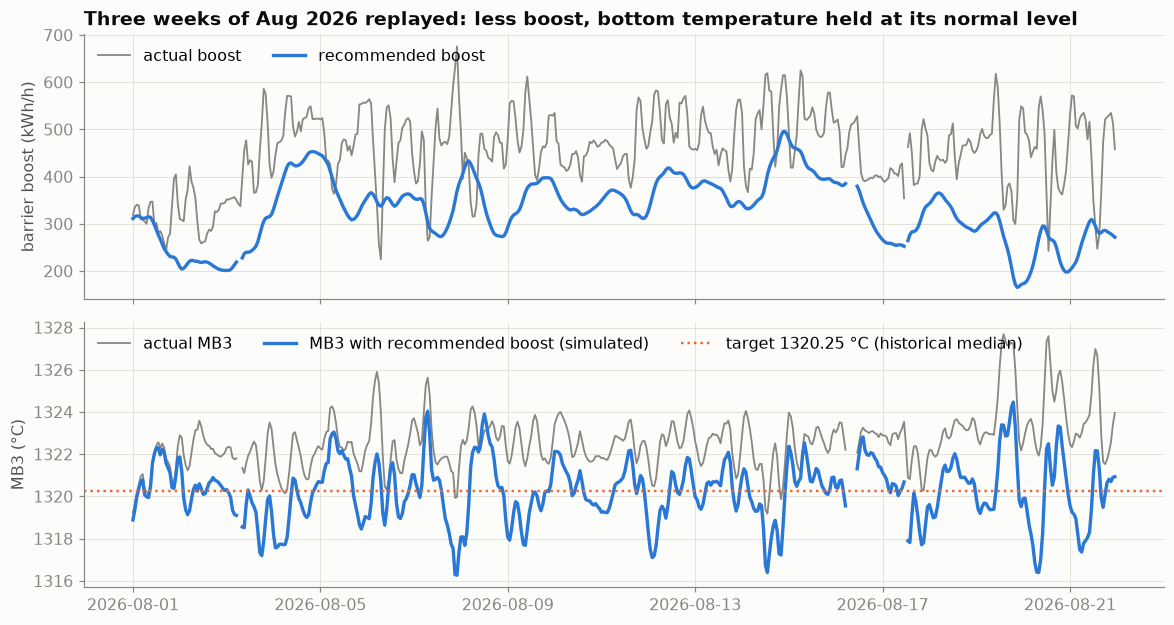

In [11]:
R.chart_boost_replay(D)

**Reading:** in Aug 2026, MB3 ran above its normal level. The controller reduces boost step by step, and the simulated MB3 settles around the target. **Less boost, same bottom temperature.** When MB3 runs cold (as in Sep 2026), the same controller **adds** boost.

---
## 7. Results of the complete recommender (gas + boost + air)
All walk-forward, all setpoints inside the historical limits.

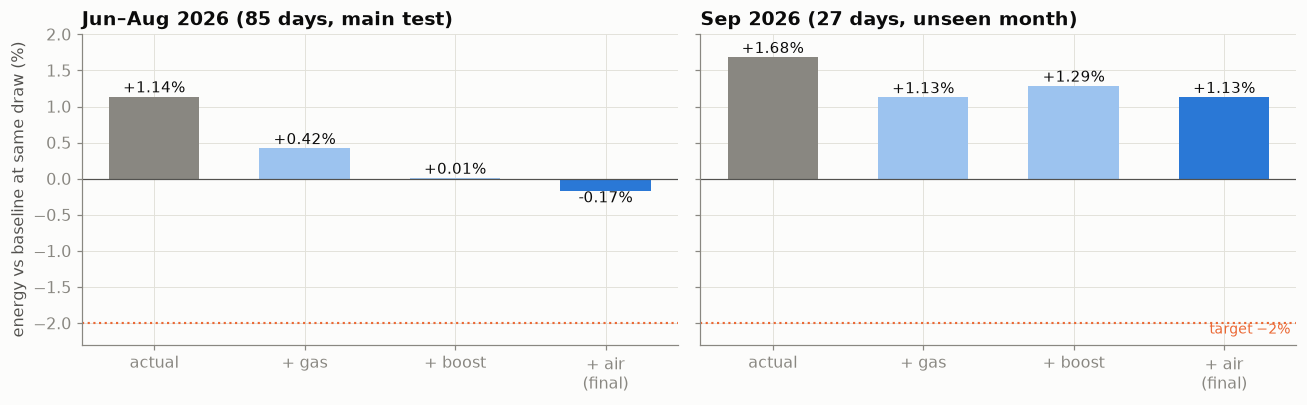

,Jun–Aug: SFC,Jun–Aug: saving %,Jun–Aug: draw-adjusted %,Sep: SFC,Sep: saving %,Sep: draw-adjusted %
actual operation,1605.27,0.00,1.14,1610.40,0.00,1.68
+ gas recommender,1594.03,0.70,0.42,1601.35,0.56,1.13
+ barrier-boost controller,1587.75,1.09,0.01,1604.09,0.39,1.29
+ air target (final),1584.95,1.27,-0.17,1601.61,0.55,1.13


In [12]:
R.chart_scorecard(D)

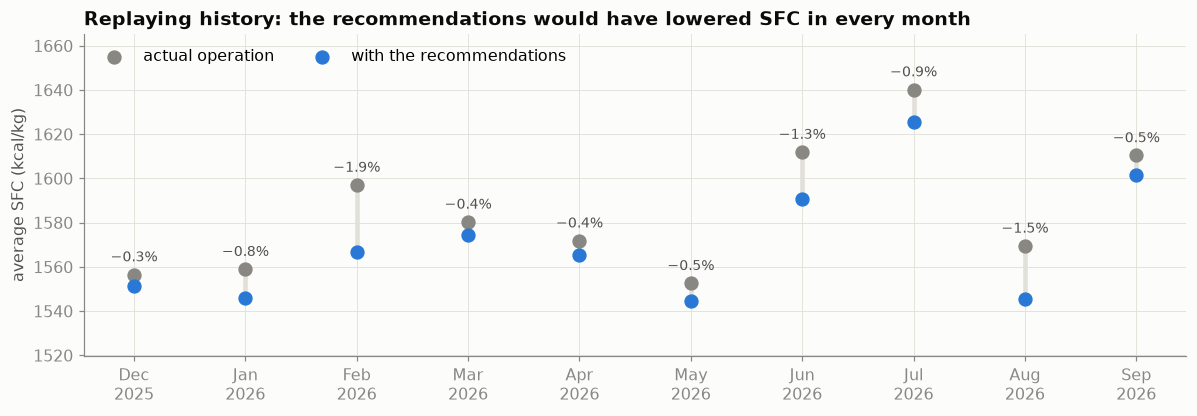

In [13]:
m = R.chart_monthly_replay(D)

**Reading**
- **Jun–Aug 2026:** SFC −1.27%; draw-adjusted from **+1.14%** above the baseline to **−0.17%**.
- **Sep 2026 (validation):** SFC −0.55%. The gas part held up (−0.56%). The bottom ran slightly cold, so the boost controller added a little boost, which costs some energy, as intended.
- **Replay Dec 2025 – Sep 2026:** **lower SFC in every month**, by 0.3% to 1.9%.
- **The remaining gap to −2%** needs the trial levers described in the insights notebook.

---
## 8. Safety: every setpoint stays inside the furnace's proven limits

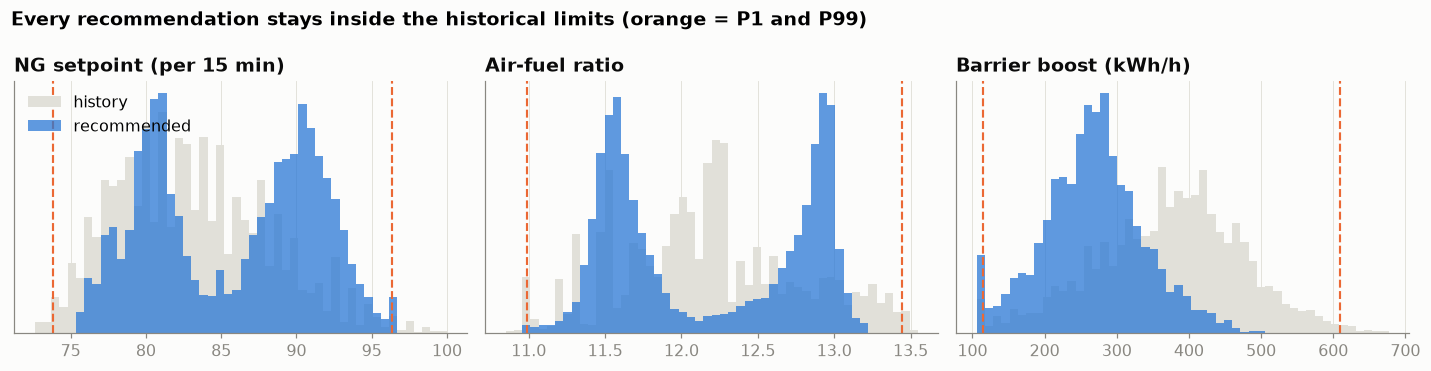

,lower limit (P1),upper limit (P99)
NG setpoint (per 15 min),73.86,96.34
air-fuel ratio,10.99,13.44
barrier boost (kWh/h),114.30,609.80
MB3 bottom temperature (°C),1316.14,1325.51
optical crown temperature (°C),1568.00,1578.00
NCV accepted (kcal/SCM),8500.00,10500.00
draw (t/day),49.10,62.22
secondary air (per 15 min),920.51,1104.22
"daily gas heat (Gcal/day, flag only)",72.54,80.90


In [14]:
R.chart_limits(D, FR)
names = {'ng_scm': 'NG setpoint (per 15 min)', 'afr': 'air-fuel ratio', 'bb_kwh_h': 'barrier boost (kWh/h)', 'mb3_temp': 'MB3 bottom temperature (°C)',
         'opt_temp': 'optical crown temperature (°C)', 'ncv': 'NCV accepted (kcal/SCM)', 'draw_t': 'draw (t/day)',
         'sec_air': 'secondary air (per 15 min)', 'gas_day_gcal': 'daily gas heat (Gcal/day, flag only)'}
lim = pd.DataFrame(FR.limits, index=['lower limit (P1)', 'upper limit (P99)']).T.round(2)
lim.index = [names[i] for i in lim.index]
lim

Each recommendation is checked against these limits:
- **NG, secondary air, AFR and barrier boost** are held inside their historical P1–P99. A value held at a limit is marked.
- **Inputs** outside their history (NCV, draw, optical crown, MB3) are flagged.
- **If NG is already at its upper limit**, the boost controller does not reduce the boost in that hour.

Official plant limits will replace these when you provide them.

---
## 9. The recommendation function
Edit the values in the cell below and run it. You get the setpoints for the **next reversal cycle** (NG, secondary air, AFR) and the **next hour** (barrier boost), each with its allowed range.

| Input | Where it comes from |
|---|---|
| `ncv` | latest NCV (kcal/SCM), from UEMS |
| `draw_t` | expected draw today (t/day) |
| `cullet_pct` | cullet % today |
| `optical_prev24h` | average of the optical crown readings of the last 24 h (°C), used as a safety check |
| `bb_kwh_last_hour` | barrier boost in the last hour (kWh), from the database |
| `mb_kwh_last_hour` | melter boost in the last hour (kWh), from the database |
| `mb3_now` | MB3 bottom temperature now (°C), from DCS |

In [15]:
INPUTS = dict(
    date='2026-10-05',          # today
    ncv=9300,                   # latest NCV (kcal/SCM), valid 8,500-10,500
    draw_t=58.0,                # expected draw today (t/day)
    cullet_pct=18,              # cullet % today
    optical_prev24h=1574.5,     # optical crown, average of the last 24 h (°C)
    bb_kwh_last_hour=350,       # barrier boost in the last hour (kWh)
    mb_kwh_last_hour=300,       # melter boost in the last hour (kWh)
    mb3_now=1321.5,             # MB3 bottom temperature now (°C)
)
rec = FR.recommend(INPUTS)
display(R.show_recommendation(rec))
print('Warnings:', rec.attrs['flags'] if rec.attrs['flags'] else 'none: all inputs and setpoints are inside the furnace history')

,recommended,unit,allowed range (history),held at limit?
setpoint,,,,
Daily gas heat target (not a setpoint; flagged only),78.91,Gcal/day,72.54 - 80.90,no
"NG setpoint (per 15 min, workbook unit)",88.38,SCM/15 min,73.86 - 96.34,no
"Secondary air (per 15 min, workbook unit)",1041.92,SCM/15 min,920.51 - 1104.22,no
Air-fuel ratio,11.79,-,10.99 - 13.44,no
"Barrier boost, next hour",343.53,kWh/h,114.30 - 609.80,no
"Barrier boost, next hour (per 15 min)",85.88,kWh/15 min,28.57 - 152.45,no


Warnings: none: all inputs and setpoints are inside the furnace history


**How the operator uses it**
- **Every reversal cycle, by minute 15:** set **NG** (one value for both ports) and **secondary air / AFR** using the latest NCV.
- **Every hour:** set the **barrier boost**. The next gas recommendation automatically reads that boost from the database.
- **If a value is held at a limit,** or a warning appears, the shift engineer checks the plant before applying it.

### 9.1 Quick look-up tables for operators
NG setpoint (per 15 min) and AFR by NCV and draw, for typical boost levels (barrier 350 kWh/h, melter 300 kWh/h):

In [16]:
ng_tab, afr_tab = R.ng_lookup(FR)
print('NG setpoint (workbook unit per 15 min):'); display(ng_tab)
print('Air-fuel ratio:'); afr_tab

NG setpoint (workbook unit per 15 min):


,draw 52 t,draw 55 t,draw 58 t,draw 61 t
"NCV 8,600",92.0,93.8,95.6,96.3
"NCV 8,800",89.9,91.6,93.4,95.2
"NCV 9,000",87.9,89.6,91.3,93.0
"NCV 9,200",86.0,87.7,89.3,91.0
"NCV 9,400",84.1,85.8,87.4,89.1
"NCV 9,600",82.4,84.0,85.6,87.2
"NCV 9,800",80.7,82.3,83.9,85.5
"NCV 10,000",79.1,80.6,82.2,83.7
"NCV 10,200",77.5,79.1,80.6,82.1
"NCV 10,400",76.1,77.5,79.0,80.5


Air-fuel ratio:


,draw 52 t,draw 55 t,draw 58 t,draw 61 t
"NCV 8,600",10.99,10.99,10.99,10.99
"NCV 8,800",11.16,11.16,11.16,11.16
"NCV 9,000",11.41,11.41,11.41,11.41
"NCV 9,200",11.66,11.66,11.66,11.66
"NCV 9,400",11.92,11.92,11.92,11.92
"NCV 9,600",12.17,12.17,12.17,12.17
"NCV 9,800",12.42,12.42,12.42,12.42
"NCV 10,000",12.68,12.68,12.68,12.68
"NCV 10,200",12.93,12.93,12.93,12.93
"NCV 10,400",13.18,13.18,13.18,13.18


- **Reading down a column:** higher NCV → less NG, the same heat.
- Values exactly at **96.3** (NG) or **10.99** (AFR) are held at the historical limit. These are rare conditions (very lean gas at high draw), where the shift engineer checks the plant.
- **Reading across a row:** more draw → more NG.
- **AFR rises with NCV**, because richer gas needs more air per SCM.

---
## 10. Back-test: what does your history say for these input values?
`backtest_inputs(INPUTS)` finds the days in your history that looked like these inputs:
- draw within ±1.5 t, daily NCV within ±150 kcal/SCM, cullet within ±1%
- if fewer than 10 days match, the window is widened automatically

For those days it shows:
1. **the actual average SFC**: what the furnace really did
2. **the average SFC with the recommendations on the same days**: walk-forward, each day using only earlier days
3. both values **draw-adjusted** and against the **5-t band baseline**
4. **today's expected SFC** if today's recommendation is followed all day. This includes today's furnace age, so it is usually a little higher than older days; compare lines 1 and 2 for the saving
5. the **setpoints** used on those days (all, and the best 25%) next to today's recommendation

Similar days searched: draw 56.5-59.5 t, NCV 9150-9450 kcal/SCM, cullet 17.0-19.0%


,result
similar historical days,13
period covered,2025-12-01 to 2026-09-04
average draw (t/day) | NCV,58.3 | 9313
1. ACTUAL average SFC on those days (kcal/kg),"1,579.77"
"2. RECOMMENDER on the same days, walk-forward (kcal/kg)","1,560.75"
saving vs actual (%),1.20
days where the recommender was better (%),84.62
3. draw-adjusted vs baseline: actual (%),1.20
draw-adjusted vs baseline: recommender (%),-0.02
4. band 55-60 t: baseline SFC | -2% target,1566.7 | 1535.4


Setpoints: what operators used on similar days vs what is recommended now


,history: similar days (actual),history: best 25% of similar days,recommended now
"NG (per 15 min, at a similar NCV)",86.21,85.12,88.38
secondary air (per 15 min),1026.02,1008.45,1041.92
air-fuel ratio,11.91,11.86,11.79
barrier boost (kWh/h),375.91,380.79,343.53
MB3 (°C; recommended = target),1320.84,1320.59,1320.25


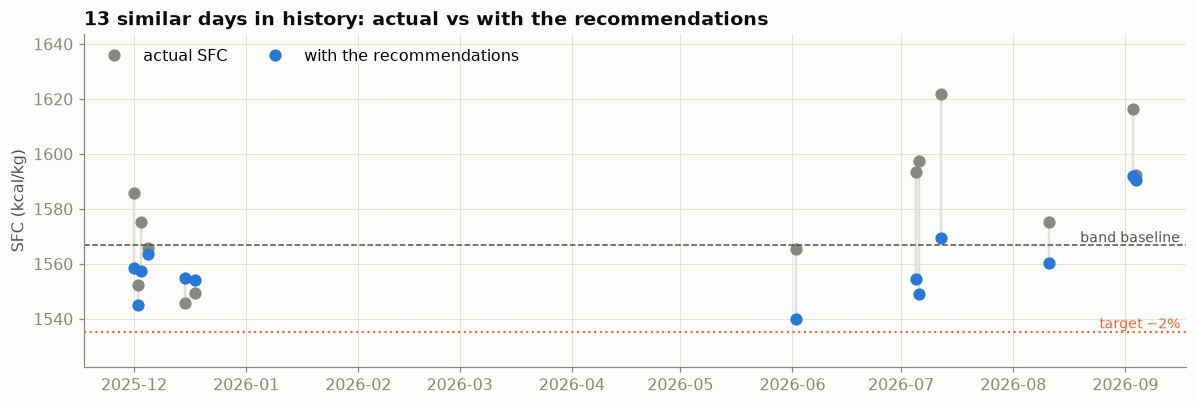

In [17]:
res = R.backtest_inputs(D, FR, INPUTS)

**Reading**
- On days like these, the recommendations would have lowered SFC on most days and on average. The saving above is a like-for-like comparison on the same days.
- Today's recommended NG can be higher than on older similar days. Two reasons:
  - the furnace is older (ageing)
  - the recommended barrier boost is lower, and each Gcal of boost removed is replaced by only ~0.77 Gcal of gas, so **total energy still falls**
- To search more widely: `R.backtest_inputs(D, FR, INPUTS, draw_tol=2, ncv_tol=250)`.

---
## 11. How it will be used in the trial
| Phase | What the recommender does |
|---|---|
| **0. Shadow (2 weeks)** | Runs live every cycle and every hour; values are logged, **not applied**. Operators compare them with their own settings |
| **1. Gas + air** | NG and secondary air / AFR set from the recommender |
| **2. + Barrier boost** | Barrier boost from the controller (MB3 target 1,320.25 °C) |
| **3. Trial levers** | One at a time: MB3 target toward 1,319.2 °C; air toward the historical P25 (with an O₂/CO check); crown setpoint −1 °C, then −2 °C |
| **4. Lock-in** | Final settings become standard; ≥ 30 days of measurement |

- **The models update themselves:** the gas model is re-fitted daily on the newest data, so it follows the furnace as it changes.
- **Daily guard-rails** (seeds, MB3, crown) stop any step that affects quality.
- **Success is measured** with the draw-adjusted and band yardsticks shown here; 30 days give about ±0.74% precision.

**What we need from the plant:**
- approval of the phased trial
- a portable O₂/CO analyser for the air step
- official limits for MB3, crown and electrodes if they are tighter than history
- agreement on the success yardstick (band or draw-adjusted, and how ageing is treated)